UPscaledEV Project Main Code
Under the funding from TotalEnergies
Author: Yizhan Gu
Email: yig031@ucsd.edu
Affiliation: UCSD CER

Readme:
This code aims at providing the baseline file for implementation. The baseline has V0G, EV opt at 100% and eta%. There is no AS or DR considered in the objective function. It's based on Yi-An Chen's sclaedev codd and more consice, robust and well-constructed.

Labels:
NOTE: means there's a note and please read it
FIXME: means it's a bug or a problem that needs solving
TODO: means it's a to-do task, but not critical to the code running
VERSION: means there're more than one version for the diversity purpose, possibly shows in objective function choices or results analyses

Acknowledgement:
I gratefully acknowledge the support from my PI Jan Kleissl and TotalEnergies team, and the contributions from Yi-An Chen, whose prior work laid the foundation for this project. Special thanks to the UCSD Grid Lab team members.

Set working path and import packages

In [ ]:
import os
from pathlib import Path
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / '2025Data').exists():
    raise FileNotFoundError(
        'Start Jupyter from the UPSCALeDEV_2024 repository root so relative data paths are reproducible.'
    )
os.chdir(PROJECT_ROOT)
print("Path is:", os.getcwd(), "\n")
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
from datetime import timedelta
from datetime import datetime
import time
from time import process_time
import calendar
import holidays
from pathlib import Path
from random import choices
import cvxpy as cp
import scs
import sys
from tqdm import tqdm
from forecast_ED_PD import KnownUser, UnKnownUser
import glob


Paramaters

In [2]:


# MPC parameters
# Configurable paths allow site-specific baseline history while preserving campus defaults.
EV_DATA_FILE = Path(globals().get('EV_DATA_FILE', '2025Data/EV_data/UCSD_AllSites_Merge_PostProcessedSession_QC.csv'))
BASELINE_OUTPUT_DIR = Path(globals().get('BASELINE_OUTPUT_DIR', 'Results_Shrinking/Dispatch'))
BASELINE_START_MONTH = int(globals().get('BASELINE_START_MONTH', 2))
BASELINE_STOP_MONTH_EXCLUSIVE = int(globals().get('BASELINE_STOP_MONTH_EXCLUSIVE', 7))
BASELINE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

dt_m_EV = 15
dt_h = dt_m_EV/60
interval = timedelta(minutes=dt_m_EV)
unit = dt_h

# Energy Prices-AL-TOU:
# Summer: off-peak period energy charge rate $0.10679/kW h
#         On-peak period energy charge rate $0.12628/kW h
# Winter: off-peak period energy charge rate $0.09506/kW h
#         On-peak period energy charge rate $0.10626/kW h
c_e_TOU_AL = np.ones((96, 1))*0.10679
c_e_TOU_AL[16*4:21*4] = 0.12628
# TODO: Add Winter rates and auto for days


# Demand Charges
c_NCD = 24.48  #24.48*0.25=6.12
c_PD = 19.14 + 9.78

# Tax
c_tax_DWR = 0.00580                               # x Total kWh
c_tax_oEESbo_Franchise = 0.0688 * c_tax_DWR       # x Total kWh
c_tax_CA_Surcharge = 0.00030                      # x Total kWh
c_tax_CA_Regulatory = 0.00058                     # x Total kWh
# x Total Bill (UDC+Commodity)
c_tax_SD_Franchise = 0.0578
c_tax_all = c_tax_DWR + c_tax_oEESbo_Franchise + c_tax_CA_Surcharge + c_tax_CA_Regulatory

# Forecast methods
Numb_EVs = 0
Numb_AbsDiffEVs = 0

Fc_SessionkWh = 'PersistenceSessionkWh'  # 'PerfectSessionkWh' #'PersistenceSessionkWh'
Fc_NumbEV = 'PersistenceNumbEV'          # 'PerfectNumbEV'     #'PersistenceNumbEV'
Fc_AtArrival = 'PerfectatArrival'    # 'PerfectatArrival'  #'MLatArrival' from Avik
Fc_building = 'Perfect'              # 'Perfectat'  #'Persistence'
Fc_PV = 'Perfect'                    # 'Perfectat'  #'Persistence'

# NOTE: This file is used to get the Dispatch file before Day0 RT implementation
DAM = 0 # 1/0: w/o day-ahead market participation (Demand Response)

#always run both the base (no service level reduction) and the case1 with service level reduction
Cases = ['Base', 'Case1']

year = 2025

Data processing

In [3]:

if Fc_AtArrival == 'MLatArrival':
    User_Data = pd.read_csv("Driver_Table.csv")
    User_known = User_Data['driver_id'][User_Data['TotSession']>10].unique()
    UserNoBess = []


# create weekdays (excluding holidays) and weekends (including holidays) lists
Holidays = holidays.US(years=year)
Holidays_dates = list(Holidays.keys())
Holidays_dates = [date for date in Holidays_dates if date.year == year]

datetime(year,1,1) in Holidays
start_ind_Y = datetime(year,1,1)
end_ind_Y = datetime(year+1,1,1)
DateSeries_ThisY = []
while start_ind_Y < end_ind_Y:
    DateSeries_ThisY.append(start_ind_Y)
    start_ind_Y += timedelta(hours=24)

DateSeries_ThisY = pd.Series(DateSeries_ThisY)
Y_Weekends = DateSeries_ThisY[DateSeries_ThisY.dt.dayofweek>=5]
Y_Holidays = DateSeries_ThisY[DateSeries_ThisY.dt.date.isin(Holidays_dates)]

Y_WeekendsWH = pd.concat([Y_Weekends,Y_Holidays],axis=0).drop_duplicates(keep='first', inplace=False).sort_values(axis=0, ascending=True).reset_index(drop=True)
Y_WeekdaysWOH = DateSeries_ThisY[~(DateSeries_ThisY.isin(Y_WeekendsWH))].sort_values(axis=0, ascending=True).reset_index(drop=True)
if len(Y_WeekdaysWOH) + len(Y_WeekendsWH) != len(DateSeries_ThisY):
    print("Error in holiday identification!\n")
    sys.exit()

# VERSION: 2025 data
# https://docs.google.com/presentation/d/1JRLf_Qb5xuxuLRH_28HUPq5HQBOIKCjCzQMGXw96MlE/edit?slide=id.g308df064212_0_68#slide=id.g308df064212_0_68
Data = pd.read_csv(EV_DATA_FILE, low_memory=False)
Data['Interval start'] = pd.to_datetime(Data['Interval start'])
Data['Interval end'] = pd.to_datetime(Data['Interval end'])
Data['Session start'] = pd.to_datetime(Data['Session start'])
Data['Session end'] = pd.to_datetime(Data['Session end'])



print('EV baseline input:', EV_DATA_FILE)
print("Number of Intervals:", len(Data))
print("Test year:", year)
print("Date range:", Data['Interval start'].min(), "to", Data['Interval start'].max())
print("Unique sites:", len(Data['Site'].unique()))
Data['Car_'] = Data['10-digit UID'].astype(str)

Number of Intervals: 374890
Test year: 2025
Date range: 2025-01-01 03:15:00 to 2025-07-31 21:00:00
Unique sites: 23


Main Loop

In [4]:

# clear last time's baseline dispatch file before running new one
dir_Output = str(BASELINE_OUTPUT_DIR / ('2025_' + Fc_SessionkWh + '_' + Fc_NumbEV + '_' + Fc_AtArrival + '_baseline.csv'))
filepath = Path(dir_Output)
if filepath.exists():
    filepath.unlink()
    print("Deleted old baseline dispatch file.")

start_RT_month = BASELINE_START_MONTH
target_RT_month = BASELINE_STOP_MONTH_EXCLUSIVE
for month in np.arange(start_RT_month, target_RT_month): # stop month is exclusive
    print("\nProcessing month:", month)
    num_days = calendar.monthrange(year,month)[1] 

    M_Th_NCD = [0 for _ in range(len(Cases)+1)]
    M_Th_PD = [0 for _ in range(len(Cases)+1)]
    M_Th_NCD_list = [[] for _ in range(len(Cases)+1)]
    M_Th_PD_list = [[] for _ in range(len(Cases)+1)]
    M_Th_NCD_list_96 = [[] for _ in range(len(Cases)+1)]
    M_Th_PD_list_96 = [[] for _ in range(len(Cases)+1)]
    
    
    M_V0G = pd.DataFrame()
    M_V1G = pd.DataFrame()
    M_Opt_Offline = pd.DataFrame()
    M_Opt_Imp = [pd.DataFrame() for _ in range(len(Cases))] #pd.DataFrame()
    M_t = pd.DataFrame()
    
    M_ED_V0G = []
    M_ED_V1G = []
    M_ED_Opt_DA = []
    M_ED_Opt_t0 = []
    M_ED_Opt_base = []
    M_ED_Opt_case1 = []
    

    for Day in tqdm(np.arange(1, num_days+1), desc="Processing days"):

        TheDate_Day0 = datetime(year, month, Day)   
        TheDate_Day0_Start = TheDate_Day0 + timedelta(seconds=0)
        TheDate_Day0_End = TheDate_Day0 + timedelta(hours=24)


        
        if len(Y_WeekdaysWOH[Y_WeekdaysWOH==TheDate_Day0])>0: 
            Order = Y_WeekdaysWOH[Y_WeekdaysWOH==TheDate_Day0].index  
            TheDate_Dayb1 = Y_WeekdaysWOH[Order-1].iloc[0]
            TheDate_Dayb2 = Y_WeekdaysWOH[Order-2].iloc[0]
            TheDate_Dayb3 = Y_WeekdaysWOH[Order-3].iloc[0]
        else:
            Order = Y_WeekendsWH[Y_WeekendsWH==TheDate_Day0].index  
            TheDate_Dayb1 = Y_WeekendsWH[Order-1].iloc[0]
            TheDate_Dayb2 = Y_WeekendsWH[Order-2].iloc[0]
            TheDate_Dayb3 = Y_WeekendsWH[Order-3].iloc[0]
            

        
        TheDate_Dayb1_Start = TheDate_Dayb1 + timedelta(seconds=0)
        TheDate_Dayb1_End   = TheDate_Dayb1 + timedelta(hours=24)
        TheDate_Dayb2_Start = TheDate_Dayb2 + timedelta(seconds=0)
        TheDate_Dayb2_End   = TheDate_Dayb2 + timedelta(hours=24)
        TheDate_Dayb3_Start = TheDate_Dayb3 + timedelta(seconds=0)
        TheDate_Dayb3_End   = TheDate_Dayb3 + timedelta(hours=24)
        
        TheDate        = [TheDate_Day0, TheDate_Dayb1, TheDate_Dayb2, TheDate_Dayb3]
        TheDates_Start = [TheDate_Day0_Start, TheDate_Dayb1_Start, TheDate_Dayb2_Start, TheDate_Dayb3_Start]   
        TheDates_End   = [TheDate_Day0_End, TheDate_Dayb1_End, TheDate_Dayb2_End, TheDate_Dayb3_End]
        
        
        # 2025 new LMP data
        dir_Input_DA = os.path.join("2025Data/LMP/2025/DA/")
        dir_Input_RT = os.path.join("2025Data/LMP/2025/FM/")

        filename_Input = glob.glob(dir_Input_DA + TheDate_Day0_Start.strftime('%Y%m%d') + '*.csv')
        Data_LMP_DA = pd.read_csv(''.join(filename_Input))
        filename_Input = glob.glob(dir_Input_RT + TheDate_Day0_Start.strftime('%Y%m%d') + '*.csv')
        Data_LMP_RT = pd.read_csv(''.join(filename_Input))

                
        Data_LMP_DA = Data_LMP_DA[Data_LMP_DA['LMP_TYPE']=='LMP']
        Data_LMP_RT = Data_LMP_RT[Data_LMP_RT['LMP_TYPE']=='LMP']
        
        # sort the 'INTERVALSTARTTIME_GMT'
        LMP_IntervalStartGMT_DA = Data_LMP_DA['INTERVALSTARTTIME_GMT']
        LMP_IntervalStartGMT_RT = Data_LMP_RT['INTERVALSTARTTIME_GMT']
        
        # sort LMP data based on the 'INTERVALSTARTTIME_GMT'    
        A = pd.to_datetime(LMP_IntervalStartGMT_DA)
        B = [k for k in range(len(A))]
        LMPOrder = [x for _, x in sorted(zip(A, B))]
        Data_LMP_DA_ = Data_LMP_DA.iloc[ LMPOrder, :]
        
        A = pd.to_datetime(LMP_IntervalStartGMT_RT)
        B = [k for k in range(len(A))]
        LMPOrder = [x for _, x in sorted(zip(A, B))]
        Data_LMP_RT_ = Data_LMP_RT.iloc[ LMPOrder, :]
        
        
        Bid_Pr_DA = np.array(Data_LMP_DA_['MW'].repeat(4)*0.001).reshape(96, 1)#repeat 4 times of the 24 x 1 series, $/MWh ---> $/kWh   
        Bid_Pr_RT = (np.average(np.array(Data_LMP_RT_['VALUE']).reshape(-1, 3), axis=1)*0.001).reshape(96, 1) #ave every 3 entries of the 288  x 1 series, $/MWh ---> $/kWh


            
#%%     #################################################################################
        # Choose data for Day0, Dayb1, and Dayb2
        #################################################################################

        
        
        ThisDates = []
        Data_TheDates = []       
        TimeSeries_TheDates = []
        Time_table_TheDates = []
        
        
        EnergyDemand_Table_V0G_TheDates = []
        EnergyDemand_Table_V1G_TheDates = [] 
        EnergyDemand_Step_V0G_TheDates = []
        EnergyDemand_Step_V1G_TheDates = []
        
        ArrivalTime_table_TheDates = []
        ArrivalTime_table_1_TheDates = []
        ArrivalTime_table_2_TheDates = []
        Car_table_TheDates = []
        Car_table_1_TheDates = []
        Car_table_2_TheDates = []
        Eta_min_table_TheDates = []
        Eta_min_table_1_TheDates = []
        Eta_min_table_2_TheDates = []
        IntervalkWh_max_TheDates = []
        IntervalkWh_max_1_TheDates = []
        IntervalkWh_max_2_TheDates = []
        SessionkWh_table_TheDates = []
        SessionkWh_table_1_TheDates = []
        SessionkWh_table_2_TheDates = []        
        Type_table_TheDates = []
        Type_table_1_TheDates = []
        Type_table_2_TheDates = []

        D_Th_NCD_96 = [[],[]]
        D_Th_PD_96  = [[],[]]
        
        
        for i_d in range(3): # Day0, Dayb1, Dayb2
            
            # Create Time Series for the Day               
            start_ind = TheDates_Start[i_d]
            end_ind = TheDates_End[i_d]
            TimeSeries_ThisDate = []
            while start_ind < end_ind:
                TimeSeries_ThisDate.append(start_ind)
                start_ind += interval
                                    
            # Filter the data based on the Date you choose
            Data_ThisDate = Data[(TheDates_Start[i_d] <= Data['Interval start']) & (Data['Interval start'] < TheDates_End[i_d])]

            # An empty site-day is a physical zero-EV day, not missing data.
            # Keep the exact calendar-day time axis; substituting the previous
            # day would duplicate timestamps and fabricate EV sessions.
            if len(Data_ThisDate) == 0:
                print("No EV sessions for {0}; retaining the exact calendar day with zero EV load".format(TheDates_Start[i_d]))
                

            #ThisDates = ThisDates + [ThisDate]
            Data_TheDates = Data_TheDates + [Data_ThisDate]
             
            TimeSeries_TheDates = TimeSeries_TheDates + [TimeSeries_ThisDate]    
            Time_table_TheDates = Time_table_TheDates + [pd.DataFrame(TimeSeries_ThisDate, columns=["Interval start"]) ]  
            
                
                
            #################################################################################
            # Availability table (Time series x  Vehicles)
            ################################################################################# 
           
            AllCar_table_max_charger = pd.DataFrame(columns=["Interval start"])
            AllCar_table_float_V0G = pd.DataFrame(columns=["Interval start"])
            AllCar_table_float_V1G = pd.DataFrame(columns=["Interval start"])
        
            Type_list = []
            SessionkWh_list = []
            ArrivalTime_list = []
            Eta_min_list = []

            Cars = Data_ThisDate["Car_"].unique()
            
            if Fc_AtArrival == 'MLatArrival' :   
                #store Day 0, real session data for ML forecast inputs
                if i_d == 0:               
                    List = ['Car', 'User','Session start','Arrival Hour', 'Battery (kWh)','Weekday', 'Max Charging Power']
                    Sess_Car = []
                    Sess_User = []
                    Sess_SessionStart = []
                    Sess_ArrivalHr = []
                    Sess_BESS = []
                    Sess_Weekday = []
                    Sess_MaxPw = []
                    
            
            Cars2 = []
            for i in range(len(Cars)):
                CarName = Cars[i]


                #Check for Users with no sessions creating empty dataframes 
                data_Merge_ThisDate_ThisCar_Test = Data_ThisDate[Data_ThisDate["Car_"] == CarName]
                rows, columns =  data_Merge_ThisDate_ThisCar_Test.shape
               
                if rows > 2:
                    data_Merge_ThisDate_ThisCar = Data_ThisDate[Data_ThisDate["Car_"] == CarName]
                    data_Merge_ThisDate_ThisCar = data_Merge_ThisDate_ThisCar.sort_values('Interval start')
                                        
                    # Round up/down the arrival/departure time for V1G, V0G, and Opt
                    AvailableSlots = len(data_Merge_ThisDate_ThisCar)
                    if data_Merge_ThisDate_ThisCar["Session start"].iloc[0] > data_Merge_ThisDate_ThisCar["Interval start"].iloc[0]:
                        AvailableSlots = AvailableSlots - 1
                        data_Merge_ThisDate_ThisCar = data_Merge_ThisDate_ThisCar.iloc[1:,:]
                    if data_Merge_ThisDate_ThisCar["Session end"].iloc[0] < data_Merge_ThisDate_ThisCar["Interval end"].iloc[-1]:
                        AvailableSlots = AvailableSlots - 1    
                        data_Merge_ThisDate_ThisCar = data_Merge_ThisDate_ThisCar.iloc[:AvailableSlots,:] 
                
                    Cars2 = Cars2 + [CarName]        
    
            
                    Type = data_Merge_ThisDate_ThisCar['Type'].iloc[0]
                    Type_list = Type_list + [Type]        
                    # Max interval kWh from the CHarger:
                    #    Tesla Charger            80A * 208V * 0.25hr * 0.001 = 4.160 kWh
                    #    AeroVironment:           32A * 208V * 0.25hr * 0.001 = 1.664 kWh 6.656 kW
                    if Type == 'Tesla':
                        IntervalkWh_CH_max = 4.16
                    else:
                        IntervalkWh_CH_max = 1.664
                    
                    # adjust intervalkWh_V1G if SessionkWh_V1G > numb of available intervals * IntervalkWh_CH_max 
                    SessionkWh = sum(data_Merge_ThisDate_ThisCar['Interval kWh'])
                    if SessionkWh > AvailableSlots*IntervalkWh_CH_max:
                        ratio = AvailableSlots*IntervalkWh_CH_max/SessionkWh
                        
                        # modify interval data (decrease V1G)
                        data_Merge_ThisDate_ThisCar['Interval kWh'] = data_Merge_ThisDate_ThisCar['Interval kWh']*ratio
                        #also need to modify session data (decrease SessionkWh)
                        SessionkWh = SessionkWh*ratio
                        
                    
                    SessionkWh_list = SessionkWh_list + [SessionkWh]
            
                    # there might be two session start!!
                    ArrivalTime = data_Merge_ThisDate_ThisCar["Session start"].sort_values(ascending=True).iloc[0]
                    ArrivalTime_list = ArrivalTime_list + [ArrivalTime]
    
                    # Eta_min
                    Eta_min = data_Merge_ThisDate_ThisCar['Eta'].iloc[0]
                    Eta_min_list = Eta_min_list + [Eta_min]
                    
            
                    # Interval time series during plug-in time
                    #IntervalStart_ThisCar = pd.to_datetime(data_Merge_ThisDate_ThisCar["Interval start"])
                    IntervalStart_ThisCar_round = pd.to_datetime(data_Merge_ThisDate_ThisCar["Interval start"])
            
                    
            
                    # CHarger capacity: IntervalkWh_ThisCar_CH
                    IntervalkWh_ThisCar_CH = pd.Series(range(AvailableSlots))*0 + IntervalkWh_CH_max            
                    ThisCar_table_float_max_charger = pd.DataFrame(list(zip(IntervalStart_ThisCar_round, IntervalkWh_ThisCar_CH)), columns=["Interval start", CarName])            
                    ThisCar_table_float_max_charger_ = pd.merge(Time_table_TheDates[i_d], ThisCar_table_float_max_charger, how="left", on=["Interval start"])
                    AllCar_table_max_charger = AllCar_table_max_charger.merge(ThisCar_table_float_max_charger_,  on="Interval start", how='outer')
    
                    
                    if Fc_AtArrival == 'MLatArrival' : 
                        #store Day 0, real session data for ML forecast inputs
                        if i_d == 0:
                            Sess_Car = Sess_Car + [CarName]
                            Sess_User = Sess_User + [data_Merge_ThisDate_ThisCar['User'].iloc[0]]
                            
                            ArrivalTime = data_Merge_ThisDate_ThisCar['Session start'].iloc[0]
                            Sess_SessionStart = Sess_SessionStart + [ArrivalTime] 
                            Sess_ArrivalHr = Sess_ArrivalHr + [ArrivalTime.hour + ArrivalTime.minute/60]
                            
                            #based on 'User', import BESS info from Byron's master sheet
                            UserBess = pd.read_csv ('PowerFlex input for EV statistics to be plugged into master sheet_2024.csv')
                            BESS_kWh = UserBess['Battery (kWh)'][UserBess['Doe Id']==int(Sess_User[0])]
    
                            if len(BESS_kWh)==0:
                                BESS_kWh = 48 #which is the avg BESS kWh of the master sheet
                                UserNoBess = UserNoBess + [data_Merge_ThisDate_ThisCar['User'].iloc[0]]
                            Sess_BESS = Sess_BESS + [BESS_kWh]
                            
                            Sess_Weekday = Sess_Weekday + [ArrivalTime.weekday()] #monday is 0
                            Sess_MaxPw = Sess_MaxPw + [IntervalkWh_CH_max*4]
            
            
            
            
                    # V0G
                    IntervalkWh_ThisCar_V0G = IntervalkWh_ThisCar_CH
                    IntervalkWh_left = SessionkWh + 0
            
                    for j in range(len(IntervalkWh_ThisCar_V0G)):
                        # j = 0
                        if IntervalkWh_left >= IntervalkWh_ThisCar_CH.iloc[j]:
                            IntervalkWh_left = IntervalkWh_left - IntervalkWh_ThisCar_CH.iloc[j]
                        else:
                            IntervalkWh_ThisCar_V0G.iloc[j] = IntervalkWh_left
                            IntervalkWh_ThisCar_V0G.iloc[j+1:] = 0
                            break
            
                    ThisCar_table_V0G = pd.DataFrame(list(zip(IntervalStart_ThisCar_round, IntervalkWh_ThisCar_V0G)), columns=["Interval start", CarName])
                    ThisCar_table_V0G_ = pd.merge(Time_table_TheDates[i_d], ThisCar_table_V0G, how="left", on=["Interval start"])
                    AllCar_table_float_V0G = AllCar_table_float_V0G.merge(ThisCar_table_V0G_,  on="Interval start", how='outer')
     
                    
                    # V1G
                    IntervalkWh_ThisCar_float_V1G = data_Merge_ThisDate_ThisCar["Interval kWh"]
                    ThisCar_table_float = pd.DataFrame(list(zip(IntervalStart_ThisCar_round, IntervalkWh_ThisCar_float_V1G)), columns=["Interval start", CarName])
                    ThisCar_table_float_ = pd.merge(Time_table_TheDates[i_d], ThisCar_table_float, how="left", on=["Interval start"])
                    AllCar_table_float_V1G = AllCar_table_float_V1G.merge(ThisCar_table_float_,  on="Interval start", how='outer')
                    


            # Availability matrix with Max CHarger capacity
            AllCar_table_max_charger = AllCar_table_max_charger.fillna(0)
            IntervalkWh_max = AllCar_table_max_charger.drop("Interval start", axis=1)
            
            
            # V0G
            AllCar_table_float_V0G = AllCar_table_float_V0G.fillna(0)
            EnergyDemand_Table_V0G = AllCar_table_float_V0G.drop("Interval start", axis=1)
            EnergyDemand_Step_V0G = EnergyDemand_Table_V0G.sum(axis=1)
            if len(EnergyDemand_Step_V0G) == 0:
                EnergyDemand_Step_V0G = pd.Series(np.zeros(len(TimeSeries_ThisDate)))
            
                           
            #V1G_real
            AllCar_table_float_V1G = AllCar_table_float_V1G.fillna(0)
            EnergyDemand_Table_V1G =  AllCar_table_float_V1G.drop("Interval start", axis=1)  # tables without time series
            EnergyDemand_Step_V1G = EnergyDemand_Table_V1G.sum(axis=1)
            if len(EnergyDemand_Step_V1G) == 0:
                EnergyDemand_Step_V1G = pd.Series(np.zeros(len(TimeSeries_ThisDate)))
            
        
        
        
            #################################################################################
            # Sort all the list based on the car arrival time
            #################################################################################       
            Cars2 = np.array(Cars2)
            
            # Create dataframes for SessionkWh, Eta_min, Arrival time, Types, and Cars
            ArrivalTime_table = pd.DataFrame(ArrivalTime_list).T
            #ArrivalTime_table.columns = Cars
            ArrivalTime_table.columns = Cars2
            #Car_table = pd.DataFrame(columns=Cars)
            Car_table = pd.DataFrame(columns=Cars2)
            Eta_min_table = pd.DataFrame(Eta_min_list).T
            #Eta_min_table.columns = Cars
            Eta_min_table.columns = Cars2
            SessionkWh_table = pd.DataFrame(SessionkWh_list).T
            #SessionkWh_table.columns = Cars
            SessionkWh_table.columns = Cars2
            Type_table = pd.DataFrame(Type_list).T
            #Type_table.columns = Cars
            Type_table.columns = Cars2
        
            # sort all tables based on the arrival time (first come first serve)        
            A = pd.to_datetime(ArrivalTime_list)
            B = [k for k in range(len(A))]
            CarOrder = [x for _, x in sorted(zip(A, B))]
            
            # Sort the order                
            ArrivalTime_table = ArrivalTime_table.iloc[:, CarOrder]
            Car_table         = Car_table.iloc[:, CarOrder]
            Eta_min_table     = Eta_min_table.iloc[:, CarOrder]
            SessionkWh_table  = SessionkWh_table.iloc[:, CarOrder]
            Type_table        = Type_table.iloc[:, CarOrder]
            IntervalkWh_max   = IntervalkWh_max.iloc[:, CarOrder]
                            
            
            

            #################################################################################
            # Seperate two types of cars: Tesla & non-Tesla
            #################################################################################                 
            
            
            if Type_table.empty or Type_table.shape[1] == 0:
                Type_table_1 = Type_table.iloc[:, 0:0].copy()
                Type_table_2 = Type_table.iloc[:, 0:0].copy()
            else:
                Type_table_1 = Type_table.loc[:,Type_table.iloc[0, :] == 'Tesla']
                Type_table_2 = Type_table.loc[:,Type_table.iloc[0, :] != 'Tesla']            
            
        
            Logic_table_select_car_1 = Car_table.columns.intersection(list(Type_table_1.columns))
            Logic_table_select_car_2 = Car_table.columns.intersection(list(Type_table_2.columns))
            
            ArrivalTime_table_1 = ArrivalTime_table[Logic_table_select_car_1]
            ArrivalTime_table_2 = ArrivalTime_table[Logic_table_select_car_2]

            Car_table_1 = Car_table[Logic_table_select_car_1]
            Car_table_2 = Car_table[Logic_table_select_car_2]
            
            Eta_min_table_1 = Eta_min_table[Logic_table_select_car_1]
            Eta_min_table_2 = Eta_min_table[Logic_table_select_car_2]
        
            IntervalkWh_max_1 = IntervalkWh_max[Logic_table_select_car_1]
            IntervalkWh_max_2 = IntervalkWh_max[Logic_table_select_car_2]
            
            SessionkWh_table_1 = SessionkWh_table[Logic_table_select_car_1]
            SessionkWh_table_2 = SessionkWh_table[Logic_table_select_car_2]


            #Put all variables of Day0, Dayb1, and Dayb2 in lists
            ArrivalTime_table_TheDates = ArrivalTime_table_TheDates + [ArrivalTime_table]
            ArrivalTime_table_1_TheDates = ArrivalTime_table_1_TheDates + [ArrivalTime_table_1]            
            ArrivalTime_table_2_TheDates = ArrivalTime_table_2_TheDates + [ArrivalTime_table_2]
            ArrivalTime_table_TheDates_ = [ArrivalTime_table_TheDates,ArrivalTime_table_1_TheDates,ArrivalTime_table_2_TheDates]
            
            Car_table_TheDates = Car_table_TheDates + [Car_table]
            Car_table_1_TheDates = Car_table_1_TheDates + [Car_table_1]
            Car_table_2_TheDates = Car_table_2_TheDates + [Car_table_2]
            Car_table_TheDates_ = [Car_table_TheDates,Car_table_1_TheDates,Car_table_2_TheDates]
            
            Eta_min_table_TheDates = Eta_min_table_TheDates + [Eta_min_table]
            Eta_min_table_1_TheDates = Eta_min_table_1_TheDates + [Eta_min_table_1]
            Eta_min_table_2_TheDates = Eta_min_table_2_TheDates + [Eta_min_table_2]  
            Eta_min_table_TheDates_ = [Eta_min_table_TheDates,Eta_min_table_1_TheDates,Eta_min_table_2_TheDates]
             
            IntervalkWh_max_TheDates = IntervalkWh_max_TheDates + [IntervalkWh_max]
            IntervalkWh_max_1_TheDates = IntervalkWh_max_1_TheDates + [IntervalkWh_max_1]
            IntervalkWh_max_2_TheDates = IntervalkWh_max_2_TheDates + [IntervalkWh_max_2]
            IntervalkWh_max_TheDates_ = [IntervalkWh_max_TheDates,IntervalkWh_max_1_TheDates,IntervalkWh_max_2_TheDates]
            
                
            SessionkWh_table_TheDates = SessionkWh_table_TheDates + [SessionkWh_table]
            SessionkWh_table_1_TheDates = SessionkWh_table_1_TheDates + [SessionkWh_table_1]
            SessionkWh_table_2_TheDates = SessionkWh_table_2_TheDates + [SessionkWh_table_2]
            SessionkWh_table_TheDates_ = [SessionkWh_table_TheDates,SessionkWh_table_1_TheDates,SessionkWh_table_2_TheDates]
            
            Type_table_TheDates = Type_table_TheDates + [Type_table]
            Type_table_1_TheDates = Type_table_1_TheDates + [Type_table_1]
            Type_table_2_TheDates = Type_table_2_TheDates + [Type_table_2]
                            
            EnergyDemand_Table_V0G_TheDates = EnergyDemand_Table_V0G_TheDates + [EnergyDemand_Table_V0G] 
            EnergyDemand_Step_V0G_TheDates = EnergyDemand_Step_V0G_TheDates + [EnergyDemand_Step_V0G]
            EnergyDemand_Table_V1G_TheDates = EnergyDemand_Table_V1G_TheDates + [EnergyDemand_Table_V1G] 
            EnergyDemand_Step_V1G_TheDates = EnergyDemand_Step_V1G_TheDates + [EnergyDemand_Step_V1G]    





        if Fc_AtArrival == 'MLatArrival' : 
            #List ['Car', 'User', 'Session start', 'Arrival Hour', 'Battery (kWh)', 'Weekday', 'Max Charging Power']
            All_Sess = pd.concat([pd.Series(Sess_Car),  pd.Series(Sess_User),    pd.Series(Sess_SessionStart), pd.Series(Sess_ArrivalHr),\
                                  pd.Series(Sess_BESS), pd.Series(Sess_Weekday), pd.Series(Sess_MaxPw)], axis=1)
            
            All_Sess.columns = List

            
        #################################################################################
        # Choose the Real and forecasted variables from Day0, or Day 1 based on the forecast
        #################################################################################

        # Real-time (include 2 cases) and Day-ahead   
        
        i_ = len(Cases)+1
        
        EmptyList = [[[] for _ in range(i_)] for _ in range(3)] # for All EVS, Tesla, non-Tesla, each has three lists 
        ArrivalTime_table_real =  [[[] for _ in range(i_)] for _ in range(3)]  #EmptyList.copy() 
        ArrivalTime_table_fc   = [[[] for _ in range(i_)] for _ in range(3)]  #EmptyList.copy()
        Car_table_real         = [[[] for _ in range(i_)] for _ in range(3)]  #EmptyList.copy()
        Car_table_fc           = [[[] for _ in range(i_)] for _ in range(3)]  #EmptyList.copy()
        Eta_min_table_real     = [[[] for _ in range(i_)] for _ in range(3)]  #EmptyList.copy()
        Eta_table_RT           = [[[] for _ in range(i_)] for _ in range(3)] 

        IntervalkWh_max_real   = [[[] for _ in range(i_)] for _ in range(3)]  #EmptyList.copy()
        IntervalkWh_max_fc     = [[[] for _ in range(i_)] for _ in range(3)]  #EmptyList.copy()
        SessionkWh_table_real  = [[[] for _ in range(i_)] for _ in range(3)]  #EmptyList.copy()
        SessionkWh_table_fc    = [[[] for _ in range(i_)] for _ in range(3)]  #EmptyList.copy()    
        
        Time_table_real        = [[] for _ in range(i_)]
        Time_table_fc          = [[] for _ in range(i_)]
        TimeSeries_real        = [[] for _ in range(i_)]
        TimeSeries_fc          = [[] for _ in range(i_)]
        
        
        #Assign real values for RT (2 cases) amd DA
        for i in range(len(Cases)+1):

            
            if (i == 0) | (i== 1):
                i_ = 0 # Day0 assigned to RT case 1 and 2
            else:
                i_ = 1 # Dayb1 assigned to DA
            for j in range(3):      #All EVs, Tela, and Non-Tesla
                #j=1
                ArrivalTime_table_real[j][i] = (ArrivalTime_table_TheDates_[j][i_]).copy()
                Car_table_real[j][i] = Car_table_TheDates_[j][i_].copy()
                Eta_min_table_real[j][i] = Eta_min_table_TheDates_[j][i_].copy() 
                
                if i == 0: #base case has Eta=100*
                    Eta_min_table_real[j][i][Eta_min_table_real[j][i]>0]=1
                    
                Eta_table_RT[j][i] = Eta_min_table_real[j][i].copy()
                #Eta_table_RT[j][i][Eta_table_RT[j][i]>0] = 1
                
                                
                IntervalkWh_max_real[j][i] = IntervalkWh_max_TheDates_[j][i_].copy()
                SessionkWh_table_real[j][i]   =  SessionkWh_table_TheDates_[j][i_].copy()    
            Time_table_real[i] = Time_table_TheDates[i_].copy() 
            TimeSeries_real[i] = TimeSeries_TheDates[i_].copy()            
            
            
            if Fc_SessionkWh == 'PerfectSessionkWh'  :
                i_ = 0
                
            elif Fc_SessionkWh == 'PersistenceSessionkWh'  :
                
                if (i == 0) | (i== 1):
                    i_ = 1 # Dayb1 assigned to RT case 1 and 2
                else:
                    i_ = 2 # Dayb2 assigned to DA
            
            for j in range(3): #All EVs, Tela, and Non-Tesla
                ArrivalTime_table_fc[j][i] = ArrivalTime_table_TheDates_[j][i_].copy()
                Car_table_fc[j][i] = Car_table_TheDates_[j][i_].copy()
                IntervalkWh_max_fc[j][i] = IntervalkWh_max_TheDates_[j][i_].copy()
                SessionkWh_table_fc[j][i]   =  SessionkWh_table_TheDates_[j][i_].copy()                
            Time_table_fc[i] = Time_table_TheDates[i_].copy()                
            TimeSeries_fc[i] = TimeSeries_TheDates[i_].copy() 
            
           
        
        
        #################################################################################
        # make the forecasted SessionkWh and IntervalkWh_max the same length as the real ones
        #################################################################################
        
        
        #For Real-time and Day-ahead optimization, and Real-time optimization has two cases: with Eta= 100% and Eta_min
        IntervalkWh_max_fc_fix = [[[] for _ in range(len(Cases)+1)] for _ in range(3)]
        SessionkWh_table_fc_fix = [[[] for _ in range(len(Cases)+1)] for _ in range(3)]
        #SessionkWh_left           =  [[[] for _ in range(len(Cases)+1)] for _ in range(3)]
        Car_table_fc_fix          =  [[[] for _ in range(len(Cases)+1)] for _ in range(3)]

            
            
            
        for i in range(len(Cases)+1):
        
            
            if (Fc_SessionkWh == 'PersistenceSessionkWh') & (Fc_NumbEV == 'PersistenceNumbEV'):
                for j in np.array(range(2))+1:
                    IntervalkWh_max_fc_fix[j][i] = IntervalkWh_max_fc[j][i].copy()
                    SessionkWh_table_fc_fix[j][i] = SessionkWh_table_fc[j][i].copy()
                    Car_table_fc_fix[j][i] = Car_table_fc[j][i].copy()
      
            elif Fc_NumbEV == 'PerfectNumbEV':
                
                # in this version, with perfect forecasted SessionkWh, Day-1 uses Day0 data, 
                # Careful! Don't trim the fc_fix variables with Day-1 real data
                # instead, just make '_fc_fix' = '_fc' given that '_fc' already equals to '_real'
                if Fc_SessionkWh == 'PerfectSessionkWh'  :
                    for j in np.array(range(2))+1:
                        IntervalkWh_max_fc_fix[j][i] = IntervalkWh_max_fc[j][i].copy()
                        SessionkWh_table_fc_fix[j][i] = SessionkWh_table_fc[j][i].copy()
                        Car_table_fc_fix[j][i] = Car_table_fc[j][i].copy()
                        
                        
                else:            
                    #i=0
                    for j in np.array(range(2))+1: # Tela, and Non-Tesla
                        #j=1
                        # trim the forecast tables
                        if len(Car_table_fc[j][i].columns) > len(Car_table_real[j][i].columns):  
                            SessionkWh_table_fc_fix[j][i] = SessionkWh_table_fc[j][i].iloc[:,0:len(Car_table_real[j][i].columns)]
                    
                            IntervalkWh_max_fc_fix[j][i] = IntervalkWh_max_fc[j][i].iloc[:,0:len(Car_table_real[j][i].columns)]
                            
                            #Car_table_fc_fix[j][i] = Car_table_fc[j][i][0:len(Car_table_real[j][i].columns)]
                            Car_table_fc_fix[j][i] = Car_table_fc[j][i].iloc[:,0:len(Car_table_real[j][i].columns)]
        
                            
                        # repeat the last n1 rows
                        # note that after repeating the last n rows, these n column names are repeated 
                            # so when calling columns, donnot call the names, but call the order
                        # note that if there was no cars, ie len(Car_table_1_fc)==0, can't repeat 
                        # note if n1_=0
                        elif (len(Car_table_fc[j][i].columns) < len(Car_table_real[j][i].columns)) & (len(Car_table_fc[j][i].columns) > 0):  
                            n1 = len(Car_table_real[j][i].columns)//len(Car_table_fc[j][i].columns)  # qoutient
                            n1_ = len(Car_table_real[j][i].columns)%len(Car_table_fc[j][i].columns)  # remainder
                                                
                            Aux1 = pd.concat([SessionkWh_table_fc[j][i]]*n1,  axis=1)
                            Aux2 = pd.concat([IntervalkWh_max_fc[j][i]]*n1,  axis=1)
                            
                                                
                            if n1_ == 0:
                                SessionkWh_table_fc_fix[j][i] = Aux1
                                IntervalkWh_max_fc_fix[j][i] = Aux2
                                
                            else:
                                SessionkWh_table_fc_fix[j][i] = pd.concat([Aux1, SessionkWh_table_fc[j][i].iloc[:, -n1_:]], axis=1) 
                                IntervalkWh_max_fc_fix[j][i] = pd.concat([Aux2, IntervalkWh_max_fc[j][i].iloc[:, -n1_:]], axis=1)
                                
                                
                            #Car_table_fc_fix[j][i] = pd.DataFrame(IntervalkWh_max_fc_fix[j][i].columns)
                            Car_table_fc_fix[j][i] = pd.DataFrame(columns=IntervalkWh_max_fc_fix[j][i].columns)
                        
                        # have to use perfect fc if no data from yesterday!!!   
                        # ex: on Dec 27th, no Tesla arrived yesterday(Dec. 26th)
                        elif len(Car_table_fc[j][i]) == 0:
                            SessionkWh_table_fc_fix[j][i] = SessionkWh_table_real[j][i].copy()
                            IntervalkWh_max_fc_fix[j][i] = IntervalkWh_max_real[j][i].copy()
                            Car_table_fc_fix[j][i] = Car_table_real[j][i].copy()
                    
                        else:
                            SessionkWh_table_fc_fix[j][i] = SessionkWh_table_fc[j][i].copy()
                            IntervalkWh_max_fc_fix[j][i] = IntervalkWh_max_fc[j][i].copy()
                            Car_table_fc_fix[j][i] = Car_table_fc[j][i].copy()
                                
                
                
            # Combine Type1 (Tesla) and Type2 (Non-Tesla) for optimization    
            SessionkWh_table_fc_fix[0][i] = pd.concat([SessionkWh_table_fc_fix[1][i], SessionkWh_table_fc_fix[2][i]], axis=1)   
            IntervalkWh_max_fc_fix[0][i] = pd.concat([IntervalkWh_max_fc_fix[1][i], IntervalkWh_max_fc_fix[2][i]], axis=1)
            Car_table_fc_fix[0][i] = pd.concat([Car_table_fc_fix[1][i], Car_table_fc_fix[2][i]], axis=1)

            


 


#%%     #################################################################################
        # DA/Offline CVX Optimization
        #################################################################################
        H = 96
        # RT start and end of the receding horizon
        H_Start_RT = TheDate_Dayb1 + timedelta(minutes=i*dt_m_EV)
        H_End_RT = TheDate_Dayb1 + timedelta(hours=24)


        # real start and end of the following time interval: [t, t+1)
        t_start_interval = H_Start_RT
        t_end_interval = H_Start_RT + timedelta(minutes=dt_m_EV)

        # create time series for H
        Time_table_DA = Time_table_real[2]        
        if Car_table_fc_fix[0][2].shape[1] == 0:
            _dummy_ev_col = '__NO_EV__'
            Car_table_fc_fix[0][2] = pd.DataFrame(columns=[_dummy_ev_col])
            IntervalkWh_max_fc_fix[0][2] = pd.DataFrame(np.zeros((H, 1)), columns=[_dummy_ev_col])
            SessionkWh_table_fc_fix[0][2] = pd.DataFrame([[0.0]], columns=[_dummy_ev_col])
        Operator_SumColumn = np.ones((Car_table_fc_fix[0][2].shape[1], 1))  # size: num_cars x 1
        
        Operator_SumRow = np.ones((1, H))   # size: 1 x num_step 
        c_e_TOU_AL_ = c_e_TOU_AL[:]-0.15    # also consider EV service revenue with a EV charging rate 0f $0.15/kWh
        

        # Filter for Peak demand Period
        PP_start = 16*4
        PP_end = 21*4
        Filter = 1
        
        
        #output variables for All EVs, Tesla, and Non-Tesla, each for RT (2 cases) and DA optimization
        EnergyDemand_Table_Opt_cap = [[[] for _ in range(len(Cases)+1)] for _ in range(3)]
        EnergyDemand_Step_Opt_cap = [[[] for _ in range(len(Cases)+1)] for _ in range(3)]
        
        
        # Construct the problem
        
        verbose=True
        
        # Variables
        Cost_Opt = cp.Variable(shape=(1, 1))
        EnergyDemand_Table_Opt = cp.Variable(shape=(H, Car_table_fc_fix[0][2].shape[1]))
        EnergyDemand_Step_Opt = cp.Variable(shape=(H, 1))

        # Objective function
        objective = cp.Minimize(Cost_Opt)
        # Constraints
        constraints = [ Cost_Opt >= c_NCD * cp.maximum(cp.atoms.max(EnergyDemand_Step_Opt/dt_h ),M_Th_NCD[2] ) \
                       + c_PD * cp.maximum(cp.atoms.max(Filter * EnergyDemand_Step_Opt[PP_start:PP_end,0 ])/dt_h , M_Th_PD[2])   \
                       + cp.sum (cp.multiply(c_e_TOU_AL_ , EnergyDemand_Step_Opt ) ),\
                   EnergyDemand_Table_Opt @ Operator_SumColumn  == EnergyDemand_Step_Opt ,\
                   Operator_SumRow @ EnergyDemand_Table_Opt == SessionkWh_table_fc_fix[0][2] ,\
                   EnergyDemand_Table_Opt >= 0 ,EnergyDemand_Table_Opt <= IntervalkWh_max_fc_fix[0][2].iloc[:,:]]
  
        prob = cp.Problem(objective, constraints)

        result = prob.solve()

        Cost_Opt_ = Cost_Opt.value
        # print("Total Cost:", Cost_Opt_)

        EnergyDemand_Table_Opt_value = EnergyDemand_Table_Opt.value
        EnergyDemand_Table_Opt_cap[0][2] = pd.DataFrame(EnergyDemand_Table_Opt_value, columns=list(Car_table_fc_fix[0][2].columns))
        EnergyDemand_Table_Opt_cap[0][2][EnergyDemand_Table_Opt_cap[0][2] <= 0.0001] = 0

        EnergyDemand_Table_Opt_cap[1][2] = EnergyDemand_Table_Opt_cap[0][2].iloc[:, :len(Car_table_fc_fix[1][2])]
        EnergyDemand_Table_Opt_cap[2][2] = EnergyDemand_Table_Opt_cap[0][2].iloc[:, len(Car_table_fc_fix[2][2]):]
        EnergyDemand_Step_Opt_cap[0][2] = EnergyDemand_Table_Opt_cap[0][2].sum(axis=1)


        dispatch_Offline = EnergyDemand_Table_Opt_cap[0][2]    
    
           
        M_Th_NCD[2] = np.maximum(max((dispatch_Offline.sum(axis=1))/dt_h),M_Th_NCD[2])
        M_Th_PD[2] = np.maximum(max((dispatch_Offline.sum(axis=1)[16*4:21*4])/dt_h),M_Th_PD[2])
        
        
        M_Th_NCD_list[2] = M_Th_NCD_list[2] + [M_Th_NCD[2]]
        M_Th_PD_list[2] = M_Th_PD_list[2] + [M_Th_PD[2]]
        
        
        #################################################################################
        # Attatch daily results to get monthly dataframe
        #################################################################################
    
            
        M_ED_V0G = M_ED_V0G + [sum(EnergyDemand_Step_V0G_TheDates[0])]       
        M_ED_V1G = M_ED_V1G + [sum(EnergyDemand_Step_V1G_TheDates[0])] 
        M_ED_Opt_DA = M_ED_Opt_DA + [sum(dispatch_Offline.sum(axis=1))]

        D_all = pd.DataFrame({'Interval start': pd.Series(TimeSeries_real[0]), \
                              'V0G [kWh]': EnergyDemand_Step_V0G_TheDates[0],\
                              'V1G_real [kWh]': EnergyDemand_Step_V1G_TheDates[0],\
                              'Opt_DA [kWh]': dispatch_Offline.sum(axis=1),\
                              'Opt_RT_t0 [kWh]': np.nan,\
                              'Base [kWh]': dispatch_Offline.sum(axis=1),\
                              'Case1 [kWh]': dispatch_Offline.sum(axis=1),\
                              'baseline_Base': np.nan,\
                              'baseline_Case1': np.nan,\
                              'NCD_Base': np.nan,\
                              'PD_Base': np.nan,\
                              'NCD_Case1': np.nan,\
                              'PD_Case1': np.nan})
        
        LMP_DA_table = pd.DataFrame({'LMP_DA': pd.Series(Bid_Pr_DA.reshape(96))})
        D_all = pd.concat([ D_all, LMP_DA_table], axis=1)
        LMP_RT_table = pd.DataFrame({'LMP_RT': pd.Series(Bid_Pr_RT.reshape(96))})
        D_all = pd.concat([ D_all, LMP_RT_table ], axis=1) 

        #attach event hours
        for i in range(len(Cases)):
            temp = pd.DataFrame({'event hour_' +Cases[i]: np.zeros(len(D_all)) })
            D_all = pd.concat([ D_all, temp], axis=1)
            
    
        dir_Output = str(BASELINE_OUTPUT_DIR / (
            TheDate_Day0.strftime("%Y") + '_' + Fc_SessionkWh + '_' + Fc_NumbEV + '_' + Fc_AtArrival + '_baseline.csv'
        ))

        filepath = Path(dir_Output)
        if filepath.exists():
            D_all.to_csv(dir_Output, mode='a', index=False, header=False)
        else:
            filepath.parent.mkdir(parents=True, exist_ok=True)
            D_all.to_csv(dir_Output, mode='w', index=False, header=True)
        


        

        #################################################################################
        # Plot Energy Demand with Optimal control algorithm
        #################################################################################

        xmin = pd.to_datetime(TimeSeries_real[0][0])
        xmax = pd.to_datetime(TimeSeries_real[0][-1]+timedelta(minutes=dt_m_EV))
        ymin = -3
        ymax = 46
        ymax_pw = 203
        
        xmin_ZoomIn = pd.to_datetime(TimeSeries_real[0][64])
        xmax_ZoomIn = pd.to_datetime(TimeSeries_real[0][84])
        ymin_ZoomIn = -3
        ymax_ZoomIn = 20
                    



    #%% #################################################################################
        # Stair plot
        #################################################################################    
        t = pd.to_datetime(TimeSeries_real[0]) + timedelta(minutes=dt_m_EV/2)            
        
        t2 = TimeSeries_real[0].copy()
        t2.append(TimeSeries_real[0][-1] + timedelta(minutes=dt_m_EV))
        
        t3 = t2[0:2]
        
        Pw_V0G_max = pd.Series(np.asarray(EnergyDemand_Step_V0G_TheDates[0], dtype=float).reshape(-1) / unit).reindex(range(H), fill_value=0.0)
        Pw_V1G = pd.Series(np.asarray(EnergyDemand_Step_V1G_TheDates[0], dtype=float).reshape(-1) / unit).reindex(range(H), fill_value=0.0)
        Pw_Opt_Offline = pd.Series(np.asarray(dispatch_Offline.sum(axis=1), dtype=float).reshape(-1) / unit).reindex(range(H), fill_value=0.0)
        
        
        Pw_V0G_max_stair       = pd.concat([pd.Series([Pw_V0G_max.iloc[0]])      ,Pw_V0G_max], ignore_index=True)
        Pw_V1G_stair           = pd.concat([pd.Series([Pw_V1G.iloc[0]])          ,Pw_V1G], ignore_index=True)
        Pw_Opt_Offline_stair   = pd.concat([pd.Series([Pw_Opt_Offline.iloc[0]])  ,Pw_Opt_Offline], ignore_index=True)


        V0G,           = plt.step(t2, Pw_V0G_max_stair      , linestyle=':', color='k', linewidth=0.5)
        V1G,           = plt.step(t2, Pw_V1G_stair          , linestyle='--', color='k', linewidth=0.5)
        Opt_DA,        = plt.step(t2, Pw_Opt_Offline_stair  , linestyle='--', color='tab:blue', linewidth=3)



        plt.title("Offline and Implemented EV scheduling on " + TheDate_Day0.strftime("%Y/%m/%d"))
        plt.xlabel('Time [-]')
        plt.ylabel('Power Demand [kW]') 
        plt.legend([Opt_DA, V0G, V1G],
                   [r'$V1G_{opt,DA,100\%}$', r'$V0G_{100\%}$',   r'$V1G_{real,100\%}$'],
        bbox_to_anchor=(1.4, 1.0),
        ncol=1,
        fontsize=12,
        frameon=False) 

        plt.gcf().autofmt_xdate()
        myFmt = mdates.DateFormatter('%H:%M')
        plt.gca().xaxis.set_major_formatter(myFmt)
        plt.xticks(rotation=45)
        plt.xlim(xmin, xmax)
        # plt.ylim(ymin, ymax_pw)
  

        path = 'Results_Shrinking/Plots/Baseline/' +\
                    TheDate_Day0.strftime("%Y") +'_' +Fc_SessionkWh+'_'+Fc_NumbEV+'_'+Fc_AtArrival +'/'
                    
        if not os.path.exists(path):
            os.makedirs(path)
        plt.savefig(path  + TheDate_Day0.strftime("%Y%m%d") + '_Implemented_Pw_stair.png', dpi=300, bbox_inches='tight')
        # plt.show()
        plt.close()
        
        pass
        
        
        
print('Finished all scenarios!')


Processing month: 2


Processing days: 100%|██████████| 28/28 [00:48<00:00,  1.72s/it]



Processing month: 3


Processing days: 100%|██████████| 31/31 [00:52<00:00,  1.69s/it]



Processing month: 4


...


Processing month: 5


Processing days: 100%|██████████| 31/31 [00:58<00:00,  1.88s/it]



Processing month: 6


Processing days: 100%|██████████| 30/30 [00:44<00:00,  1.48s/it]

Finished all scenarios!


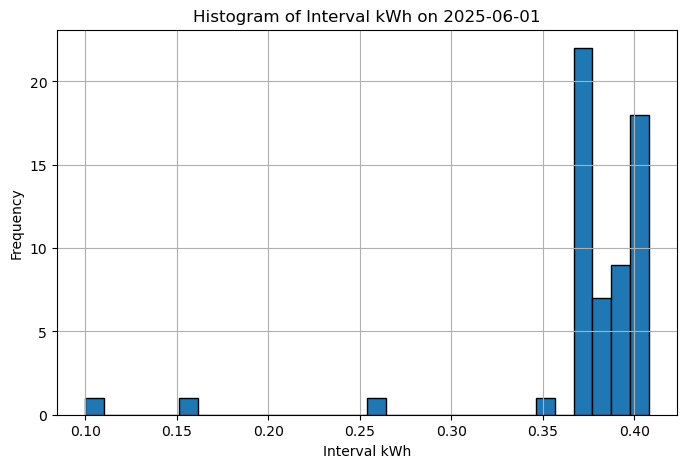

V0G energy on 06, 01, 2025: 21.663000000000004 kWh
V1G real energy on 06, 01, 2025: 21.663 kWh
V1G Dispatch energy on 06, 01, 2025: 21.662999214882404 kWh



In [5]:
# Analysis for June 1, 2025 abnormal low power

Data_0601 = Data[(datetime(2025, 6, 1, 0, 0) <= Data['Interval start']) & (Data['Interval start'] < datetime(2025, 6, 2, 0, 0))]

plt.figure(figsize=(8, 5))
plt.hist(Data_0601['Interval kWh'], bins=30, color="tab:blue", edgecolor='black')
plt.title('Histogram of Interval kWh on 2025-06-01')
plt.xlabel('Interval kWh')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


dispatch_baseline = pd.read_csv("Results_Shrinking/Dispatch/2025_PerfectSessionkWh_PerfectNumbEV_PerfectatArrival_baseline.csv")
dispatch_baseline['Interval start'] = pd.to_datetime(dispatch_baseline['Interval start'])
D_all_0601 = dispatch_baseline[(dispatch_baseline['Interval start'] >= datetime(2025, 6, 1, 0, 0)) & (dispatch_baseline['Interval start'] < datetime(2025, 6, 2, 0, 0))]

print("V0G energy on 06, 01, 2025:", D_all_0601['V0G [kWh]'].sum(), "kWh")
print("V1G real energy on 06, 01, 2025:", D_all_0601['V1G_real [kWh]'].sum(), "kWh")
print("V1G Dispatch energy on 06, 01, 2025:", D_all_0601['Opt_DA [kWh]'].sum(), "kWh\n")